In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.cross_decomposition import PLSRegression

In [9]:
with open("../data/02-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/02-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/trials_df.pkl","rb") as f:
    trials_df =pickle.load(f)
with open("../data/02-result/indications_df.pkl","rb") as f:
    indications_df =pickle.load(f)
with open("../data/01-result/embeddings_df.pkl","rb") as f:
    embeddings_df =pickle.load(f)
with open("../data/01-result/fingerprints_df.pkl","rb") as f:
    fingerprints_df =pickle.load(f)

In [10]:
FIG_PATH = "../results/figures/03-"
TAB_PATH = "../results/tables/03-"

# LaTeX-friendly settings
plt.rcParams.update({
    # "text.usetex": True,      
    "font.size": 10,           
    "axes.labelsize": 10,
    "xtick.labelsize": 8,     
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "lines.linewidth": 1
})
plt.rcParams["figure.figsize"] = (8, 6)

# Overview

In [11]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (1412, 95)
Diseases:
    (150, 84)
Trials:
    (14316, 12)
Indications:
    (5816, 12)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1029, 101)


In [12]:
indications_df["overall_success"].value_counts()

overall_success
False    1935
True      970
Name: count, dtype: Int64

# Label stability

/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_4319/354207083.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset["overall_success_plot"] = subset["overall_success_plot"].fillna("Missing")


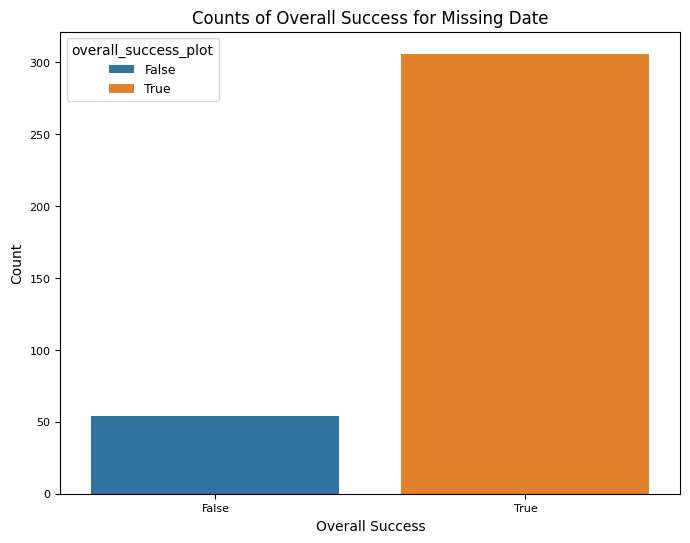

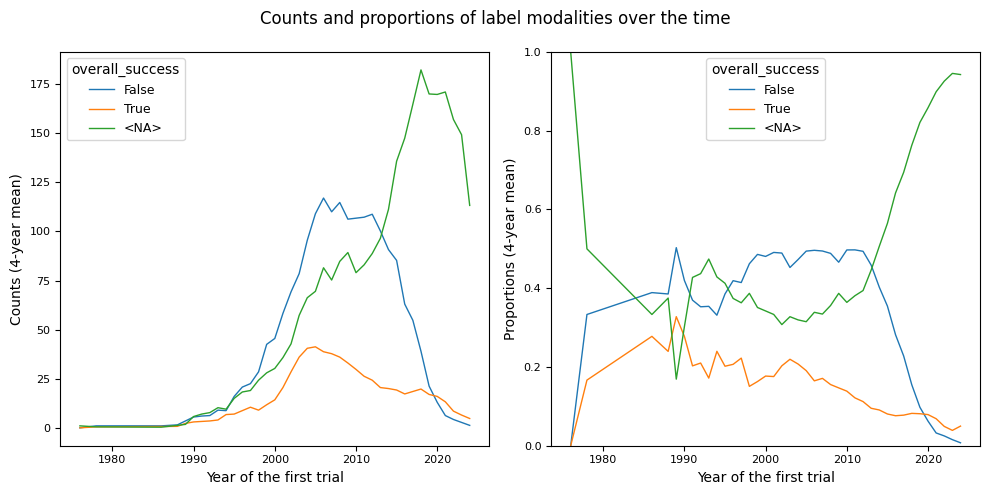

In [13]:
df = indications_df[["overall_success", "first_trial_date"]].copy()

df.loc[df["first_trial_date"] == "9999", "first_trial_date"] = pd.NaT

df["first_trial_date"] = pd.to_datetime(
    df["first_trial_date"],
    yearfirst=True,
    format="mixed",
    errors="coerce"
)


df["year"] = df["first_trial_date"].dt.year 

subset = df[df["year"].isna()].copy()

subset["overall_success_plot"] = subset["overall_success"].astype(object)
subset["overall_success_plot"] = subset["overall_success_plot"].fillna("Missing")

counts = subset["overall_success_plot"].value_counts()

sns.barplot(x=counts.index, y=counts.values, hue=counts.index)
plt.xlabel("Overall Success")
plt.ylabel("Count")
plt.title("Counts of Overall Success for Missing Date")
plt.savefig(FIG_PATH+"label-distribution_missing_date.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(1,2, figsize=(10,5))
axes = axes.flat

counts_year = (
    df.groupby(["year", "overall_success"], dropna=False)
    .size()
    .unstack(fill_value=0)
)

counts_year.index.name = "year"

counts_year.rolling(window=4, min_periods=1).mean().plot( ax=axes[0])
axes[0].set_ylabel("Counts (4-year mean)")
axes[0].set_xlabel("Year of the first trial")

proportions = counts_year.div(counts_year.sum(axis=1), axis=0)
proportions.rolling(window=4, min_periods=1).mean().plot(ax=axes[1])
axes[1].set_ylabel("Proportions (4-year mean)")
axes[1].set_xlabel("Year of the first trial")
axes[1].set_ylim(0, 1)

fig.suptitle("Counts and proportions of label modalities over the time")
plt.tight_layout()
plt.savefig(FIG_PATH+"label-stability_in_time.png", dpi=300, bbox_inches="tight")
plt.show()



**ClinicalTrials.gov registry started in 2000**, any clinical study conducted earlier is not automatically in ClinicalTrials.gov unless someone retrospectively registered it. **In 2007 it became obligatory to publish** intervention studies there :) 

Furthermore, recent studies lack results...

Decided to keep 2000-2010 for stable label estimates.

In [14]:
INCLUDE_MISSING_DATE = False
TIME_PERIOD = ("1990","2020")

if INCLUDE_MISSING_DATE:
    indications_df = indications_df[
    (indications_df["first_trial_date"] == "9999") | 
    (indications_df["first_trial_date"]> TIME_PERIOD[0]) & 
    (indications_df["first_trial_date"] < TIME_PERIOD[1]) 
    ]
else :
    indications_df = indications_df[
        (indications_df["first_trial_date"]> TIME_PERIOD[0]) & 
        (indications_df["first_trial_date"] < TIME_PERIOD[1]) 
        ]
   

In [15]:
indications_df["overall_success"].value_counts()

overall_success
False    1856
True      626
Name: count, dtype: Int64

# Missing values before merging

In [16]:
# drugs_df.isnull().sum().sort_values(ascending=False)
drugs_df = drugs_df.dropna(subset=["targets"])
drugs_df = drugs_df[drugs_df.drug_path_str.str.len()>0]
drugs_df = drugs_df[~drugs_df["withdrawn_flag"]]
drugs_df = drugs_df.drop(columns=["max_phase","helm_notation", "first_approval", "usan_year", "usan_stem_definition",
                                  "standard_inchi_key", "standard_inchi", "canonical_smiles", "full_molformula",
                                  "withdrawn_flag", "black_box_warning", "first_in_class", "molecule_type",
                                    "targets", "drug_path_str"])

diseases_df  = diseases_df[diseases_df.disease_path_str.str.len()>0]
diseases_df = diseases_df.drop(columns=["description", "associatedTargets", "phenotypes",
                                         "disease_targets", "disease_path_str"])


indications_df = indications_df.dropna(subset=["overall_success"])

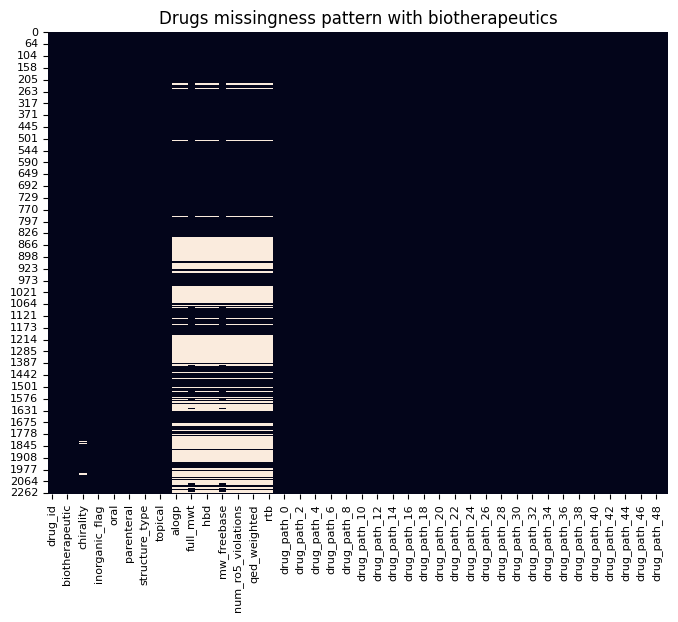

In [17]:
sns.heatmap(drugs_df.isnull(), cbar=False)
plt.title("Drugs missingness pattern with biotherapeutics")
plt.savefig(FIG_PATH+"na-drugs_with_bioth.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
drugs_df = drugs_df[~drugs_df["biotherapeutic"].astype(bool)]
drugs_df = drugs_df.drop(columns=["biotherapeutic"])

In [19]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (584, 79)
Diseases:
    (149, 79)
Trials:
    (14316, 12)
Indications:
    (2482, 12)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1029, 101)


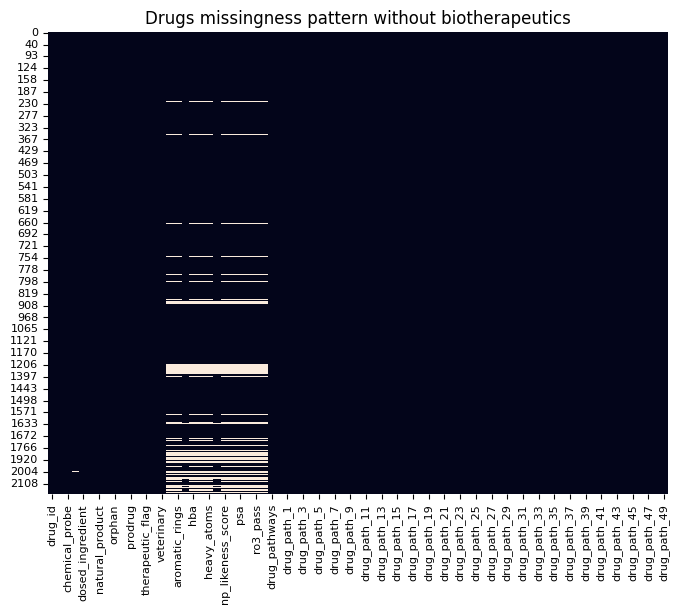

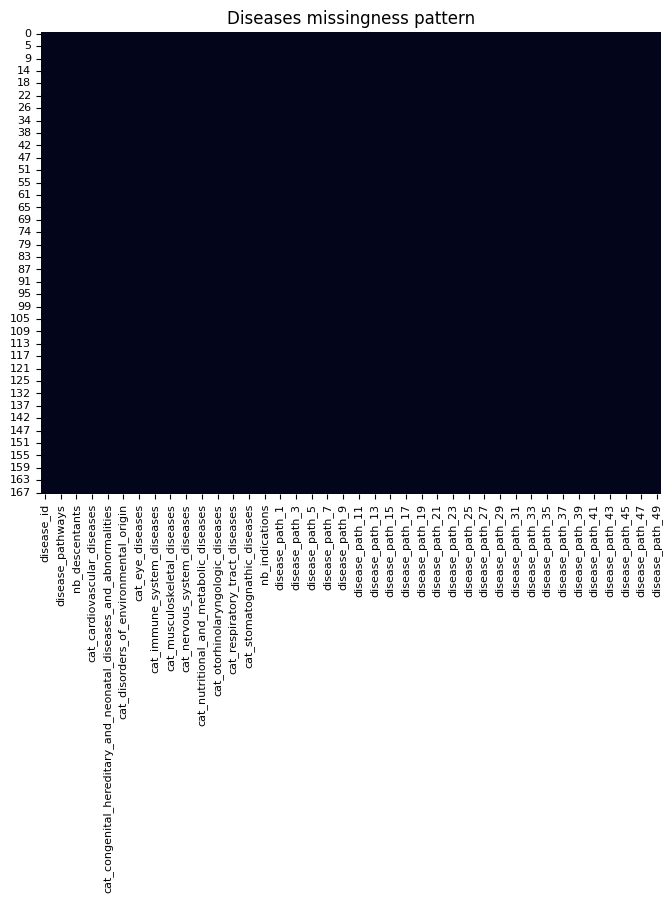

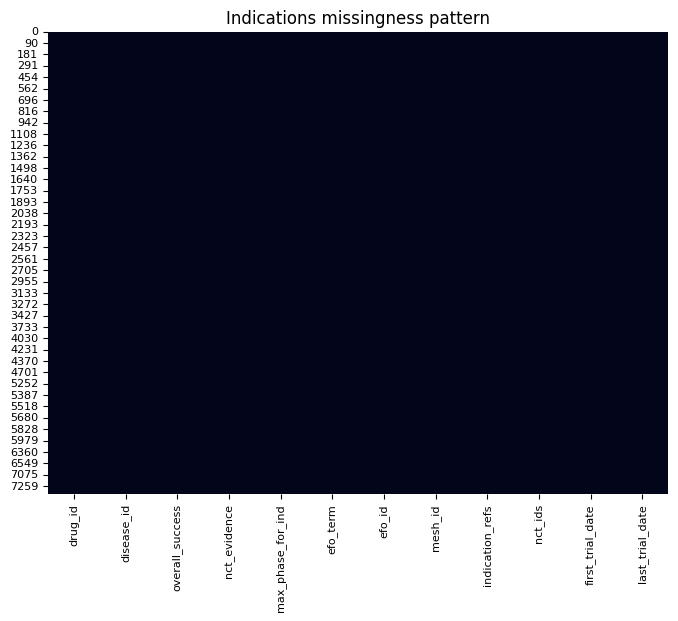

In [20]:
sns.heatmap(drugs_df.isnull(), cbar=False)
plt.title("Drugs missingness pattern without biotherapeutics")
plt.savefig(FIG_PATH+"na-drugs_wo_bioth.png", dpi=300, bbox_inches="tight")
plt.show()

sns.heatmap(diseases_df.isnull(), cbar=False)
plt.title("Diseases missingness pattern")
plt.savefig(FIG_PATH+"na-diseases.png", dpi=300, bbox_inches="tight")
plt.show()

sns.heatmap(indications_df.isnull(), cbar=False)
plt.title("Indications missingness pattern")
plt.savefig(FIG_PATH+"na-indications.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
encoded = pd.get_dummies(drugs_df["chirality"], drop_first=True, dummy_na=True, prefix="chirality_").astype(int) # "achiral" as baseline
drugs_df = drugs_df.drop(columns=["chirality"]).join(encoded)

should_be_num_features = ["dosed_ingredient", "alogp","full_mwt",
             "mw_freebase", "np_likeness_score", "psa", "qed_weighted"]
for col in should_be_num_features:
    drugs_df[col] = pd.to_numeric(drugs_df[col], errors="coerce")

drugs_df["ro3_pass"] = drugs_df["ro3_pass"].str.lower().map({"y": 1, "n":0})

knn_imp = KNNImputer(n_neighbors=5)
num_features = drugs_df.select_dtypes(include=np.number).columns
drugs_df[num_features] = knn_imp.fit_transform(drugs_df[num_features])

# Merge all

In [22]:
drugs_df = drugs_df.merge(fingerprints_df, on="drug_id")
diseases_df["disease_id"] = diseases_df["disease_id"].str.replace("_",":")
embeddings_df["disease_id"] = embeddings_df["disease_id"].str.replace("_",":")
merged_df = (indications_df[["drug_id", "disease_id", "overall_success"]]
             .merge(drugs_df, on="drug_id")
             .merge(diseases_df, on="disease_id")
             .merge(embeddings_df[["drug_id", "disease_id","name_similarity"]], on =["drug_id", "disease_id"]))

For each combination drug-disease, add Jaccard similarity between their pathway lists.

**NOTE:** `drug_path_...` and `disease_path_...` are correspining TF-IDF embeddings obtained from pathway lists of drugs and dieseases **separately**. So TF-IDF capture pathway similarities among all drugs and among all diseases separately, whereas Jaccard similarity compares pathway similarity of a pair drug-disease.

In [23]:
for i, comb in merged_df.iterrows():
    drug_path = set(comb["drug_pathways"])
    disease_path = set(comb["disease_pathways"])
    merged_df.loc[i,"path_similarity"] = len(drug_path & disease_path) / len(drug_path | disease_path)

In [24]:
merged_df = (merged_df[["drug_id","disease_id", "drug_name", "disease_name"]]
             .join(merged_df.select_dtypes(exclude=["object"])))
merged_df = merged_df.rename(columns={"overall_success" : "success"})
merged_df = merged_df.dropna(subset=["success"])
merged_df

,drug_id,disease_id,drug_name,disease_name,success,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,...,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity,path_similarity
0,CHEMBL1467,EFO:0000574,allopurinol,lymphoma,True,0.0,True,0.0,1.0,True,...,0.059033,0.010177,0.022739,0.025845,-0.018419,0.097060,0.119767,-0.031803,0.075028,0.000000
1,CHEMBL514800,EFO:0000274,apremilast,atopic eczema,False,0.0,True,0.0,1.0,True,...,-0.053554,-0.021766,-0.084058,0.008390,-0.029524,0.137635,0.056527,-0.082699,0.094691,0.061224
2,CHEMBL1471,EFO:0001378,aprepitant,multiple myeloma,False,1.0,True,0.0,0.0,True,...,-0.039626,0.102304,0.052196,-0.054368,-0.111585,0.069974,-0.017977,-0.011334,0.082487,0.000000
3,CHEMBL1370,EFO:0005854,budesonide,allergic rhinitis,True,0.0,True,0.0,1.0,True,...,-0.024492,-0.016646,0.010379,0.000958,-0.005237,0.043800,0.038987,-0.027547,0.249712,0.346154
4,CHEMBL118,EFO:0000685,celecoxib,rheumatoid arthritis,True,0.0,True,0.0,0.0,True,...,-0.062240,-0.114656,-0.027825,0.116645,0.011251,-0.015933,-0.020421,-0.065952,0.221504,0.025641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,CHEMBL5315122,EFO:0001378,bortezomib d-mannitol,multiple myeloma,True,0.0,True,0.0,0.0,False,...,-0.039626,0.102304,0.052196,-0.054368,-0.111585,0.069974,-0.017977,-0.011334,0.373565,0.035242
913,CHEMBL5315122,EFO:0005952,bortezomib d-mannitol,non-Hodgkins lymphoma,False,0.0,True,0.0,0.0,False,...,0.045815,0.003465,0.024596,0.025044,-0.005083,0.073364,0.083546,-0.046653,0.035080,0.086022
914,CHEMBL5315122,EFO:0009441,bortezomib d-mannitol,Waldenstrom macroglobulinemia,False,0.0,True,0.0,0.0,False,...,-0.000751,0.013721,0.210663,0.085218,0.045686,-0.094768,0.042072,0.093143,0.174289,0.472868
915,CHEMBL5315122,EFO:1001469,bortezomib d-mannitol,Mantle cell lymphoma,True,0.0,True,0.0,0.0,False,...,0.006981,-0.022378,0.032124,0.055562,0.013946,0.061612,0.058267,-0.011192,0.106201,0.214765


In [25]:
print(f"Merged data:\n  {merged_df.shape}")
merged_df["success"].value_counts()

Merged data:
  (917, 260)


success
False    657
True     260
Name: count, dtype: Int64

# Remove invariant columns

In [26]:
num_col_unique = merged_df.select_dtypes(include=['number', 'bool', 'object']).nunique()
merged_df = merged_df.drop(columns = num_col_unique.index[num_col_unique == 1])

# Control the duplicates

In [27]:
# Print the number of duplicates in each DataFrame
print(f"Trials duplicates (nct_id): {trials_df['nct_id'].duplicated().sum()}")
print(f"Indications duplicates (disease_id, drug_id): {indications_df[['disease_id','drug_id']].duplicated().sum()}")
print(f"Drugs duplicates (drug_id): {drugs_df[['drug_id']].duplicated().sum()}")
print(f"Diseases duplicates (disease_id): {diseases_df[['disease_id']].duplicated().sum()}")
print(f"Merged duplicates (disease_id, drug_id): {merged_df[['disease_id','drug_id']].duplicated().sum()}")

# Drop duplicates immediately after (if needed)
trials_df = trials_df.drop_duplicates(subset='nct_id')
indications_df = indications_df.drop_duplicates(subset=['disease_id','drug_id'])
drugs_df = drugs_df.drop_duplicates(subset='drug_id')
diseases_df = diseases_df.drop_duplicates(subset='disease_id')
merged_df = merged_df.drop_duplicates(subset=['disease_id','drug_id'])

Trials duplicates (nct_id): 0
Indications duplicates (disease_id, drug_id): 0
Drugs duplicates (drug_id): 0
Diseases duplicates (disease_id): 0
Merged duplicates (disease_id, drug_id): 0


# Keep track of data size

In [29]:
import pandas as pd
from pathlib import Path

# Example shapes
datasets = {
    "Drugs": drugs_df.shape,
    "Diseases": diseases_df.shape,
    "Trials": trials_df.shape,
    "Indications": indications_df.shape,
    "Name embeddings": embeddings_df.shape,
    "Molecular fingerprints": fingerprints_df.shape,
    "Merged data": merged_df.shape,
}

# Build a summary DataFrame
summary_df = pd.DataFrame(
    [(name, shape[0], shape[1]) for name, shape in datasets.items()],
    columns=["Dataset", "Rows", "Columns"]
)

# Add success counts if you want
if "success" in merged_df.columns:
    success_counts = merged_df["success"].value_counts()
    success_str = ", ".join(f"{k}: {v}" for k, v in success_counts.items())
    summary_df = pd.concat(
        [summary_df, pd.DataFrame([["Merged data success counts", success_str, ""]], columns=["Dataset", "Rows", "Columns"])],
        ignore_index=True
    )

print(summary_df)

# Export LaTeX
summary_df.to_latex(TAB_PATH + "dataset_summary.tex", index=False, longtable=False, escape=True)

                      Dataset                   Rows Columns
0                       Drugs                    541     181
1                    Diseases                    149      79
2                      Trials                  14316      12
3                 Indications                   2482      12
4             Name embeddings                 489939       5
5      Molecular fingerprints                   1029     101
6                 Merged data                    917     253
7  Merged data success counts  False: 657, True: 260        


# Correlations and distributions

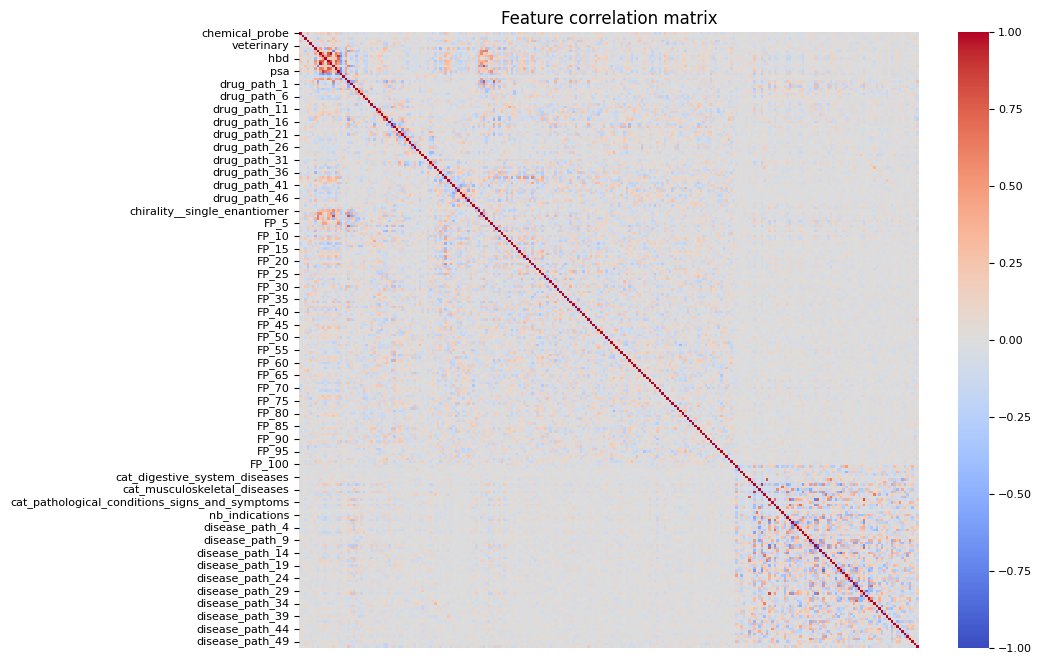

In [30]:
# don't consider some metrics
corr = (merged_df
        .select_dtypes(include=np.number)
        .corr())
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.xticks([])
plt.title("Feature correlation matrix")
plt.savefig(FIG_PATH+"corr_matrix-all_features.png", dpi=300, bbox_inches="tight")
plt.show()

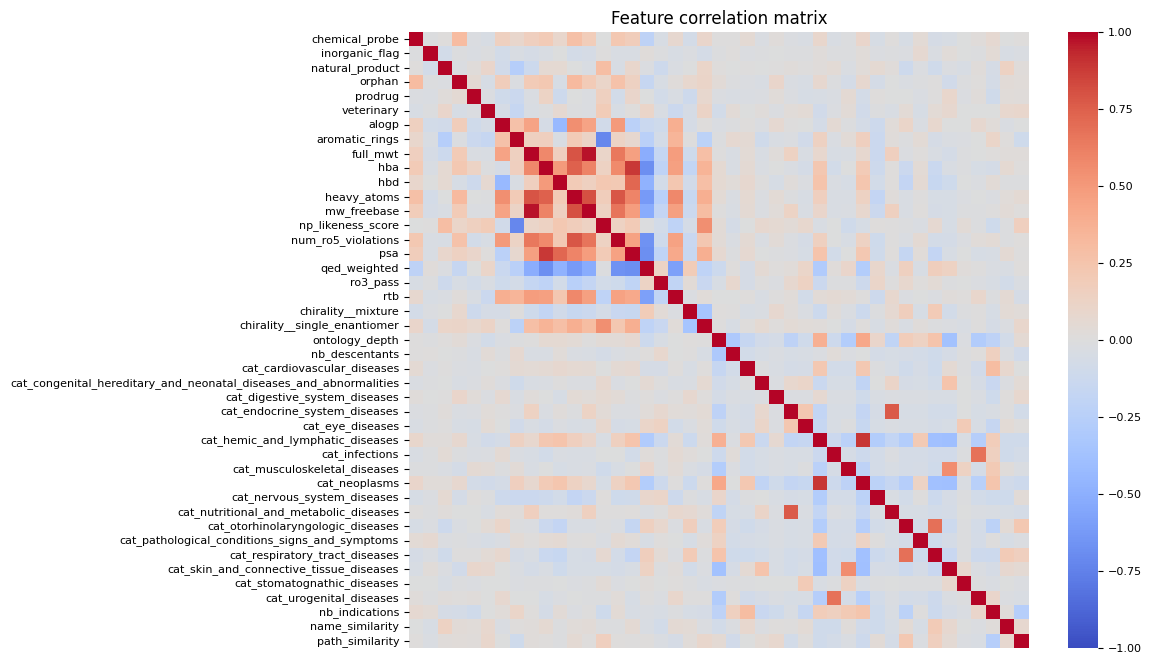

In [31]:
# close up for metrics with direct meaning
prefix_not_interpretable = ("FP", "drug_path", "disease_path")
merged_df_short = (merged_df
                .loc[:,~merged_df.columns.str.startswith(prefix_not_interpretable)]
                .select_dtypes(include=np.number))
corr = merged_df_short.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.xticks([])
plt.title("Feature correlation matrix")
plt.savefig(FIG_PATH+"corr_matrix-short.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Can be too long
# sns.set_theme(style="ticks")
# sns.pairplot(merged_df_short.join(merged_df["success"]), hue="success")

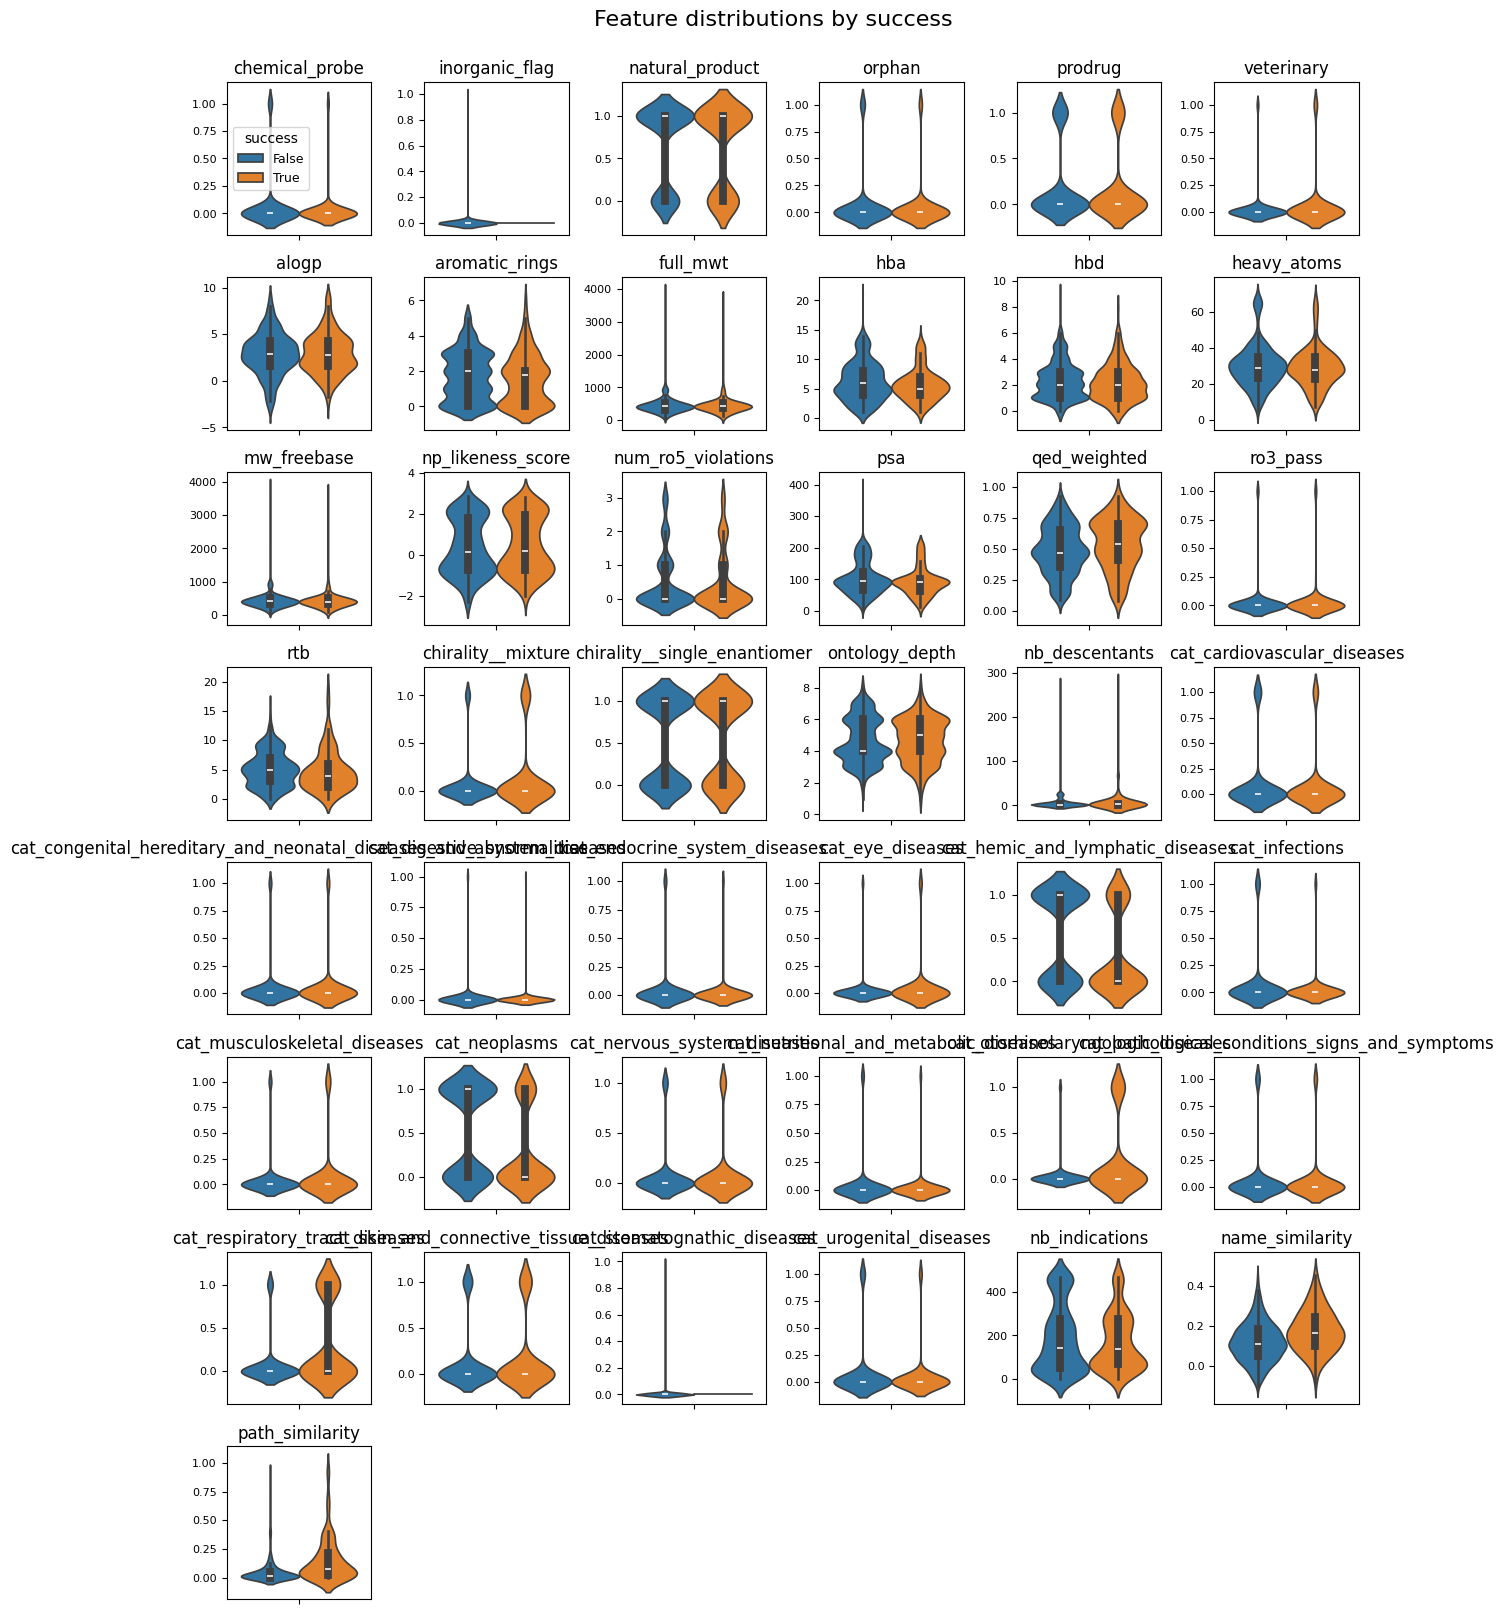

In [33]:
num_features = merged_df.select_dtypes(include=np.number).columns

n_cols = 6  # number of plots per row
n_rows = (len(num_features) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(num_features[~num_features.str.startswith(prefix_not_interpretable)]):
    sns.violinplot(y=merged_df[col], ax = axes[i], hue=merged_df["success"]);
    axes[i].set_title(col)
    axes[i].set_ylabel(None)
    if i != 0:
        axes[i].get_legend().remove()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Create one single legend for all subplots
# handles, labels = axes[i].get_legend_handles_labels()  # use first subplot
# fig.legend(handles, labels, loc='lower right', ncol=len(labels), frameon=True, fancybox=True)
fig.suptitle("Feature distributions by success", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIG_PATH+"feature_dist_by_success", dpi=300, bbox_inches="tight")
plt.show()

# Dimension reduction

In [34]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]
X_scaled = StandardScaler().fit_transform(X) # TODO: or don't scale for UMAP and tSNE?

def plot_dim_reduction(X, y, model_name="", prefix=None, filename=None):
    for label in np.unique(y):
        plt.scatter(X[y == label, 0], X[y == label, 1],
                    label= "success" if label else "fail", alpha=.5)
    if prefix is None: prefix = model_name
    plt.xlabel(prefix+"1")
    plt.ylabel(prefix+"2")
    plt.title(model_name)
    plt.legend()
    plt.grid(True)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

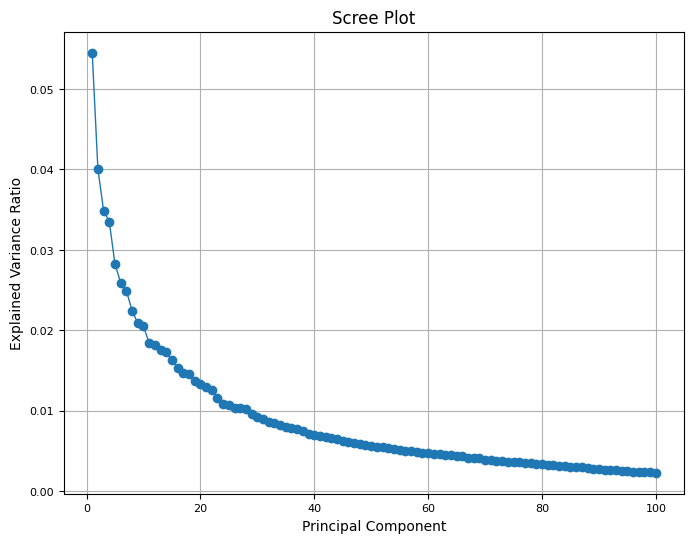

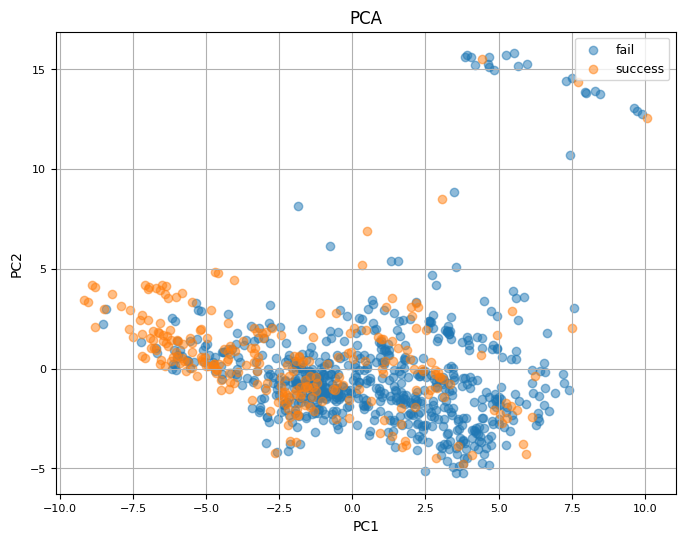

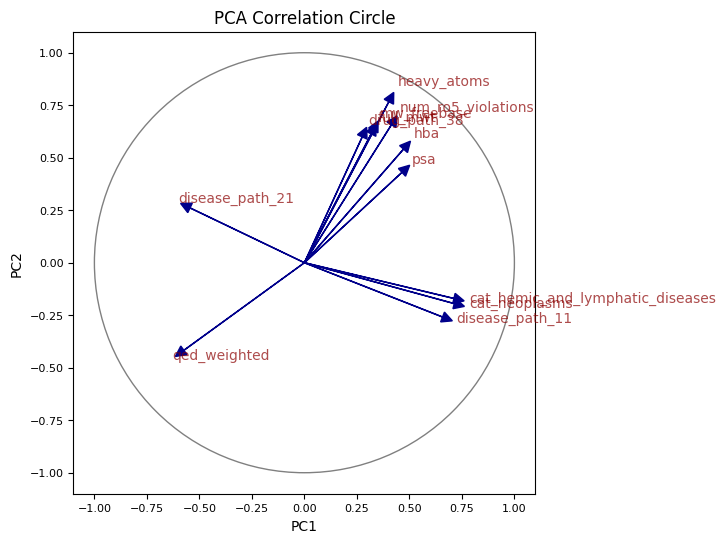

In [35]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.savefig(FIG_PATH+"pca-scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plot_dim_reduction(X_pca, y,"PCA","PC", filename=FIG_PATH+"pca-scatter_plot.png")

# Correlation circle
threshold = 0.6

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
fig, ax = plt.subplots()
circle = plt.Circle((0,0),1,color='gray',fill=False)
ax.add_artist(circle)
for i, var in enumerate(X.columns):
    length = np.sqrt(loadings[i,0]**2 + loadings[i,1]**2)
    if length > threshold:
        ax.arrow(0,0,loadings[i,0],loadings[i,1],head_width=0.05,head_length=0.05,fc='darkblue',ec='darkblue')
        ax.text(loadings[i,0]*1.1, loadings[i,1]*1.1, var, color='darkred', alpha=0.7)
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)
ax.set_aspect('equal')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Correlation Circle')
plt.savefig(FIG_PATH+"pca-corr_circle.png", dpi=300, bbox_inches="tight")
plt.show()


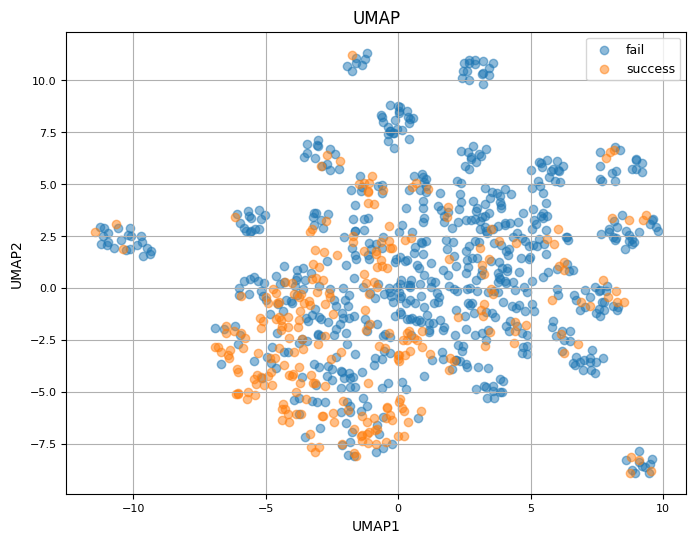

In [36]:
umap = UMAP(n_neighbors=15,min_dist=1,metric='correlation')
X_umap = umap.fit_transform(X_scaled) 
plot_dim_reduction(X_umap, y, "UMAP", filename="umap.png")

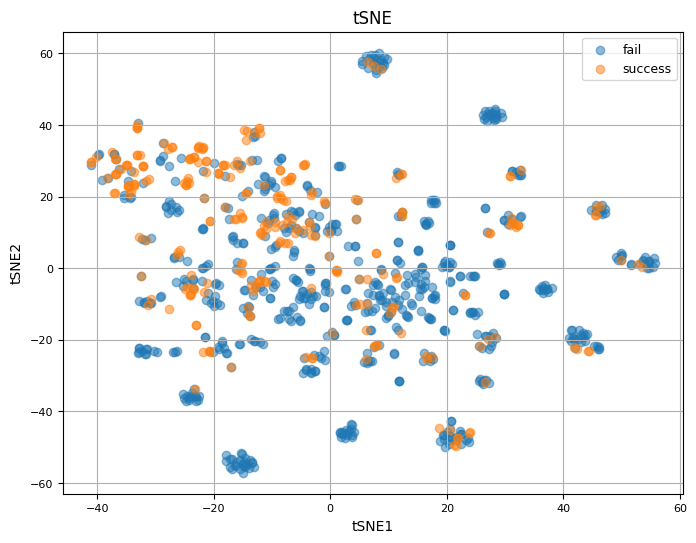

In [37]:
tsne = TSNE(n_components=2, perplexity=20)
X_tsne = tsne.fit_transform(X_scaled)
plot_dim_reduction(X_tsne, y, "tSNE", filename="tsne.png")

# Supersized dimension reduction

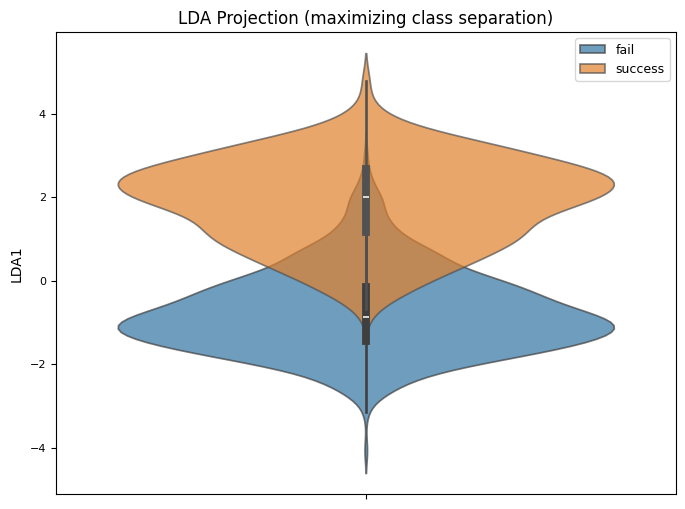

Explained variance ratio: [1.]


In [38]:
lda = LinearDiscriminantAnalysis(n_components=1)  # NOTE: n_components cannot be larger than min(n_features, n_classes - 1)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure()
# sns.violinplot(data=pd.DataFrame({"LDA1": X_lda.flat, "success" : y}), y="LDA1", label="success")
for label in np.unique(y):
        sns.violinplot(X_lda[y == label, 0], alpha=0.7, label="success" if label else "fail")
plt.ylabel("LDA1")
plt.title("LDA Projection (maximizing class separation)")
plt.legend()
plt.savefig(FIG_PATH+"lda_projection", dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", lda.explained_variance_ratio_)

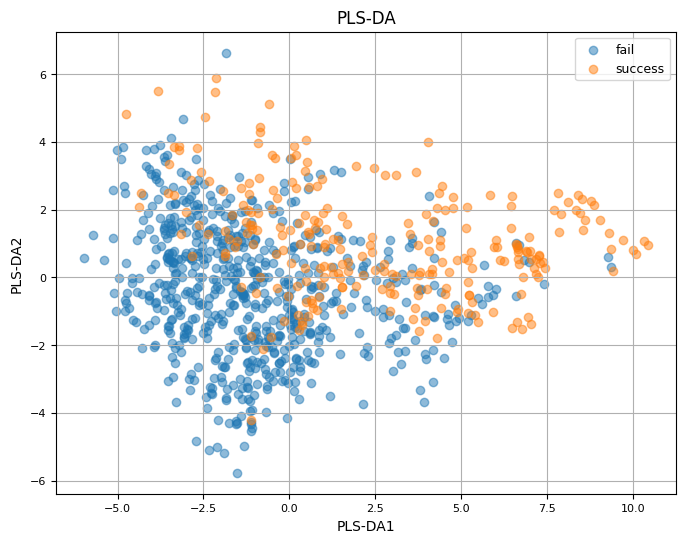

In [39]:
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, y)

X_scores = pls.x_scores_

plot_dim_reduction(X_scores, y, "PLS-DA", filename="plsda.png")

# Save results

In [40]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)